In [1]:
import os
import json

kaggle_username = "jahongirkopalov"
kaggle_key = "KGAT_345e6015e3198cf262de891b4da80ff6" 

home_dir = os.path.expanduser("~")
kaggle_dir = os.path.join(home_dir, ".kaggle")

os.makedirs(kaggle_dir, exist_ok=True)


kaggle_file_path = os.path.join(kaggle_dir, "kaggle.json")

kaggle_data = {
    "username": kaggle_username,
    "key": kaggle_key
}

with open(kaggle_file_path, "w") as f:
    json.dump(kaggle_data, f)

print(f"Kaggle.json muvaffaqiyatli yaratildi va {kaggle_file_path} ga saqlandi.")

Kaggle.json muvaffaqiyatli yaratildi va C:\Users\Jahongir\.kaggle\kaggle.json ga saqlandi.


In [2]:
import os
os.system("kaggle datasets download -d ronitf/heart-disease-uci")

1

# Yuqorida natija 0 chiqsa yaxshi ishlagan bo'lar edi, natija 1 chiqdi demak oxiriga yetmadi

In [3]:
import subprocess

result = subprocess.run(
    ["kaggle", "datasets", "download", "-d", "ineubytes/heart-disease-dataset"],
    capture_output=True, 
    text=True
)

print("Return Code:", result.returncode)
print("Output:", result.stdout)
print("Error:", result.stderr)


Return Code: 0
Output: Dataset URL: https://www.kaggle.com/datasets/ineubytes/heart-disease-dataset
License(s): unknown
heart-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)

Error: 


In [4]:
import zipfile
import pandas as pd

zip_path = r"C:\Users\Jahongir\Desktop\heart-disease-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(r"C:\Users\Jahongir\Desktop\heart-data")  
print("Dataset ochildi")

csv_path = r"C:\Users\Jahongir\Desktop\heart-data\heart.csv"

df = pd.read_csv(csv_path)

print(df.head())
print("Shape", df.shape)


Dataset ochildi
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
Shape (1025, 14)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        if df[col].nunique()<=5:
            dummies = pd.get_dummies(df[col], prefix=col, dtype=int)
            df = pd.concat([df.drop(columns=col), dummies], axis=1)
        else:
            df[col]=encoder.fit_transform(df[col])
            

In [8]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [9]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(df[numeric_cols].head())

        age  trestbps      chol   thalach   oldpeak
0  0.479167  0.292453  0.196347  0.740458  0.161290
1  0.500000  0.433962  0.175799  0.641221  0.500000
2  0.854167  0.481132  0.109589  0.412214  0.419355
3  0.666667  0.509434  0.175799  0.687023  0.000000
4  0.687500  0.415094  0.383562  0.267176  0.306452


In [10]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.479167,1,0,0.292453,0.196347,0,1,0.740458,0,0.161290,2,2,3,0
1,0.500000,1,0,0.433962,0.175799,1,0,0.641221,1,0.500000,0,0,3,0
2,0.854167,1,0,0.481132,0.109589,0,1,0.412214,1,0.419355,0,0,3,0
3,0.666667,1,0,0.509434,0.175799,0,1,0.687023,0,0.000000,2,1,3,0
4,0.687500,0,0,0.415094,0.383562,1,1,0.267176,0,0.306452,1,3,2,0


# UNS ML turlari

- Clustering
- Anomaly Detection 
- Asosation Rule Learning
- Density Estimation
- Generative Models
- Dimonsionality Reduction


# Clusteringda mavjud algoritmlar

- KMeans
- Herarchical Clustering
- DBSCAN
- Mean Shift
- Guassian Mixture
- Spectral Clustering

# K Means

K- Means Clustering Results:
Labels [4 4 4 0 2 3 2 4 0 4]
Silhoutte Score: 0.1557640168755865
Calinski-Harabasz Score: 239.4762085706532


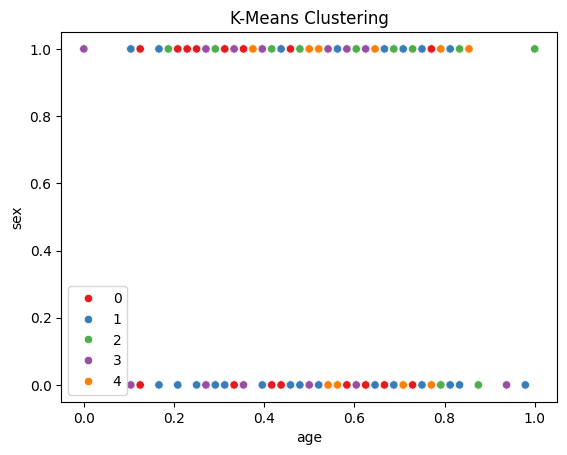

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns


features = df.drop(columns=["target"], axis=1)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(features)
sil_score = silhouette_score(features, kmeans_labels)
cal_score = calinski_harabasz_score(features, kmeans_labels)


print("K- Means Clustering Results:")
print("Labels", kmeans_labels[:10])
print("Silhoutte Score:", sil_score)
print("Calinski-Harabasz Score:", cal_score)

sns.scatterplot(x=features.iloc[:, 0], y=features.iloc[:, 1], hue=kmeans_labels, palette="Set1")
plt.title("K-Means Clustering")
plt.show()


# Hirarchical Clustering

Hierarchical Clustering Results:
Labels [0 0 0 0 1 0 1 1 0 1]
Silhouette Score: 0.172626957195589
Calinski-Harabasz Score: 231.37406561017508


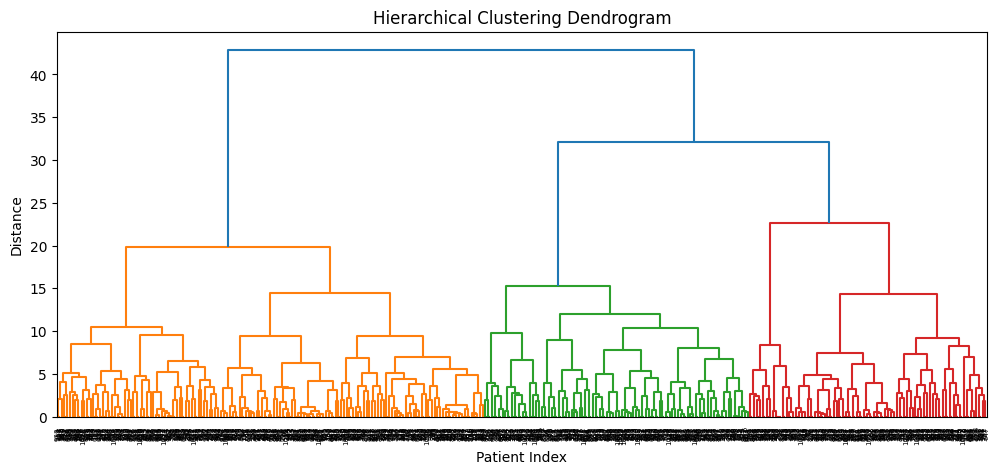

              age       sex        cp  trestbps      chol       fbs   restecg  \
cluster                                                                         
0        0.506921  0.760274  0.037671  0.350801  0.256537  0.092466  0.506849   
1        0.642296  0.754717  0.080189  0.382164  0.324007  0.202830  0.438679   
2        0.465967  0.534247  1.486301  0.334066  0.278852  0.150685  0.616438   
3        0.512917  0.940000  2.200000  0.364906  0.195753  0.060000  0.660000   
4        0.543180  0.715084  2.201117  0.360072  0.257047  0.201117  0.497207   

          thalach     exang   oldpeak     slope        ca      thal    target  
cluster                                                                        
0        0.544468  0.544521  0.180899  1.280822  0.342466  2.239726  0.342466  
1        0.489846  0.599057  0.301735  1.132075  1.985849  2.721698  0.084906  
2        0.694003  0.044521  0.050320  1.934932  0.205479  2.126712  0.900685  
3        0.653282  0.000000  0.1

In [16]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

features = df.drop(columns=["target"], axis=1)

hier = AgglomerativeClustering(n_clusters=5, linkage='ward')
hier_labels = hier.fit_predict(features)

sil_score_h = silhouette_score(features, hier_labels)
cal_score_h = calinski_harabasz_score(features, hier_labels)

print("Hierarchical Clustering Results:")
print("Labels", hier_labels[:10])   
print("Silhouette Score:", sil_score_h)
print("Calinski-Harabasz Score:", cal_score_h)

linked = linkage(features, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, labels=df.index.values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Patient Index")
plt.ylabel("Distance")
plt.show()

df["cluster"] = hier_labels
print(df.groupby("cluster").mean())

# Linkage bu ikki cluster orasidagi masofani qanday hisoblashni bildiradi

turlari

- Single - eng qisqa masofani topadi
- Complete - eng uzoq masofani topadi
- Average - ortacha masofani topadi
- Ward - klasterlar ichidagi variansni minimal qilishga harakat qiladi (koproq shu usul tavsiya qilinadi)

